# MNIST Image Classification with PyTorch

In this notebook, I build and train a neural network to classify handwritten digits from the **MNIST dataset** using PyTorch.



# Import

In [51]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

### Device Selection

Check whether a CUDA-enabled GPU is available for training:

- **CUDA** → Use the NVIDIA GPU for faster training.
- **CPU** → Used if CUDA is not available.

The selected device will be used for both the model and the training data.

In [52]:
if torch.cuda.is_available():
    device=torch.device("cuda")
    print("Cuda is available")
else:
    device=torch.device('cpu')
    print("Cuda is not available")

Cuda is available


## Preparing the MNIST Dataset

The **MNIST dataset** contains handwritten digits from **0 to 9**.

- **60,000** training images
- **10,000** test images
- Each image is **28 × 28 pixels**
- Images are **grayscale**

Before training, the images need to be converted into **PyTorch tensors** and normalized so they can be efficiently processed by the neural network.

First, I will load the MNIST dataset **without transformations** to inspect the original image format.

### Loading the Training Dataset

Load the MNIST training data using `torchvision.datasets.MNIST`:

- `root` → Location where the dataset is stored.
- `train=True` → Loads the 60,000 training images.
- `download=True` → Downloads MNIST if it is not already available locally.

In [53]:
train_dataset_without_transformation=torchvision.datasets.MNIST(
    root='./data',download=True,train=True)

### Inspecting a Sample

Each MNIST dataset item contains two values:

- **Image** → A PIL image with dimensions `28 × 28`.
- **Label** → An integer representing the handwritten digit.

A sample can be accessed using its index:

`dataset[0]` → returns `(image, label)`

For MNIST, the labels directly correspond to digits `0–9`.

In [54]:
# First sample of the dataset
image,label=train_dataset_without_transformation[0]


print(f"Image type: {type(image)} ")
print(f"Image Dimension: {image.size} ")
print(f"Label type: {type(label)} ")
print(f"Label value: {label} ")

Image type: <class 'PIL.Image.Image'> 
Image Dimension: (28, 28) 
Label type: <class 'int'> 
Label value: 5 


### Visualizing a Raw MNIST Image

Before applying transformations, MNIST pixel values range from **0 to 255**.

- `0` → Black
- `255` → White
- Values between them → Different shades of gray

The image below displays the handwritten digit along with its raw pixel values.

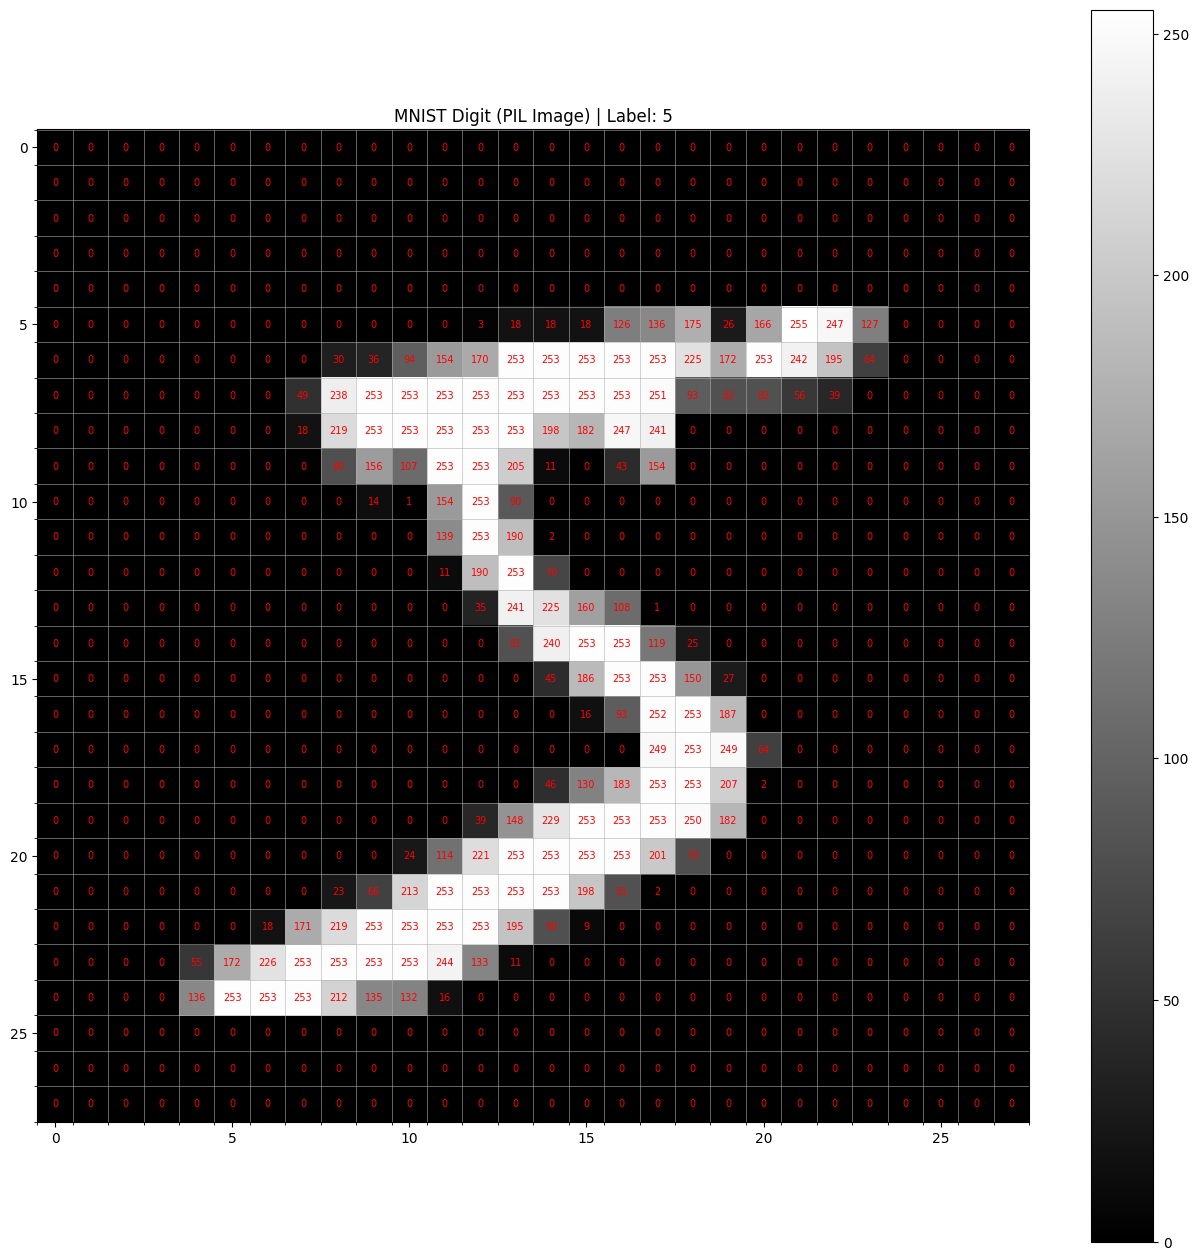

In [55]:
import numpy as np
import matplotlib.pyplot as plt

image, label = train_dataset_without_transformation[0]
image_array = np.array(image)

fig, ax = plt.subplots(figsize=(16, 16))

im = ax.imshow(image_array, cmap="gray", vmin=0, vmax=255)

# Show ALL 784 pixel values
for i in range(28):
    for j in range(28):
        value = image_array[i, j]

        ax.text(
            j, i,
            str(value),
            ha="center",
            va="center",
            fontsize=7,
            color="red"
        )

# Grid around every pixel
ax.set_xticks(np.arange(-0.5, 28, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 28, 1), minor=True)
ax.grid(which="minor", linewidth=0.4)

ax.set_title(f"MNIST Digit (PIL Image) | Label: {label}")

plt.colorbar(im, ax=ax)
plt.show()

### Applying Transformations

The raw MNIST images have pixel values between **0 and 255**. Before training, two transformations are applied:

- `ToTensor()` → Converts the PIL image into a PyTorch tensor and scales pixel values from **[0, 255] to [0, 1]**.
- `Normalize()` → Uses the MNIST dataset's mean and standard deviation to center and scale the pixel values.

`transforms.Compose()` is used to apply these transformations in sequence.

In [56]:
# Normalize() expects the mean and standard deviation as a sequence (such as a tuple).
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])

### Loading the Transformed Dataset

Load the MNIST training dataset again, this time using the transformations defined earlier.

- `transform=transform` applies the preprocessing automatically to every image when it is loaded.
- `ToTensor()` converts the image to a tensor and scales the pixels to `[0, 1]`.
- `Normalize()` normalizes the tensor using the MNIST mean and standard deviation.

In [57]:
train_dataset=torchvision.datasets.MNIST(
    root="./data",
    download=True,train=True,transform=transform
)

### Inspecting the Transformed Image

After applying the transformations:

- The image is converted from a **PIL Image** to a **PyTorch tensor**.
- The image shape becomes `(1, 28, 28)`.
- PyTorch represents images as `[channels, height, width]`.
- `1` represents the single grayscale channel.

In [58]:
# Get first sample from dataset
image,label=train_dataset[0]


print(f"Image type: {type(image)} ")
print(f"Image dimension: {image.shape} ")
print(f"Label type: {type(label)} ")
print(f"Label value: {label} ")


Image type: <class 'torch.Tensor'> 
Image dimension: torch.Size([1, 28, 28]) 
Label type: <class 'int'> 
Label value: 5 


### Visualizing the Transformed Image

After applying `ToTensor()` and `Normalize()`:

- Pixel values change from the original `[0, 255]` range to approximately `[-0.42, 2.82]`.
- Dark pixels become negative values.
- Bright pixels become positive values.
- The values are normalized using the MNIST mean and standard deviation.

Normalization helps provide consistent input values for training the neural network.

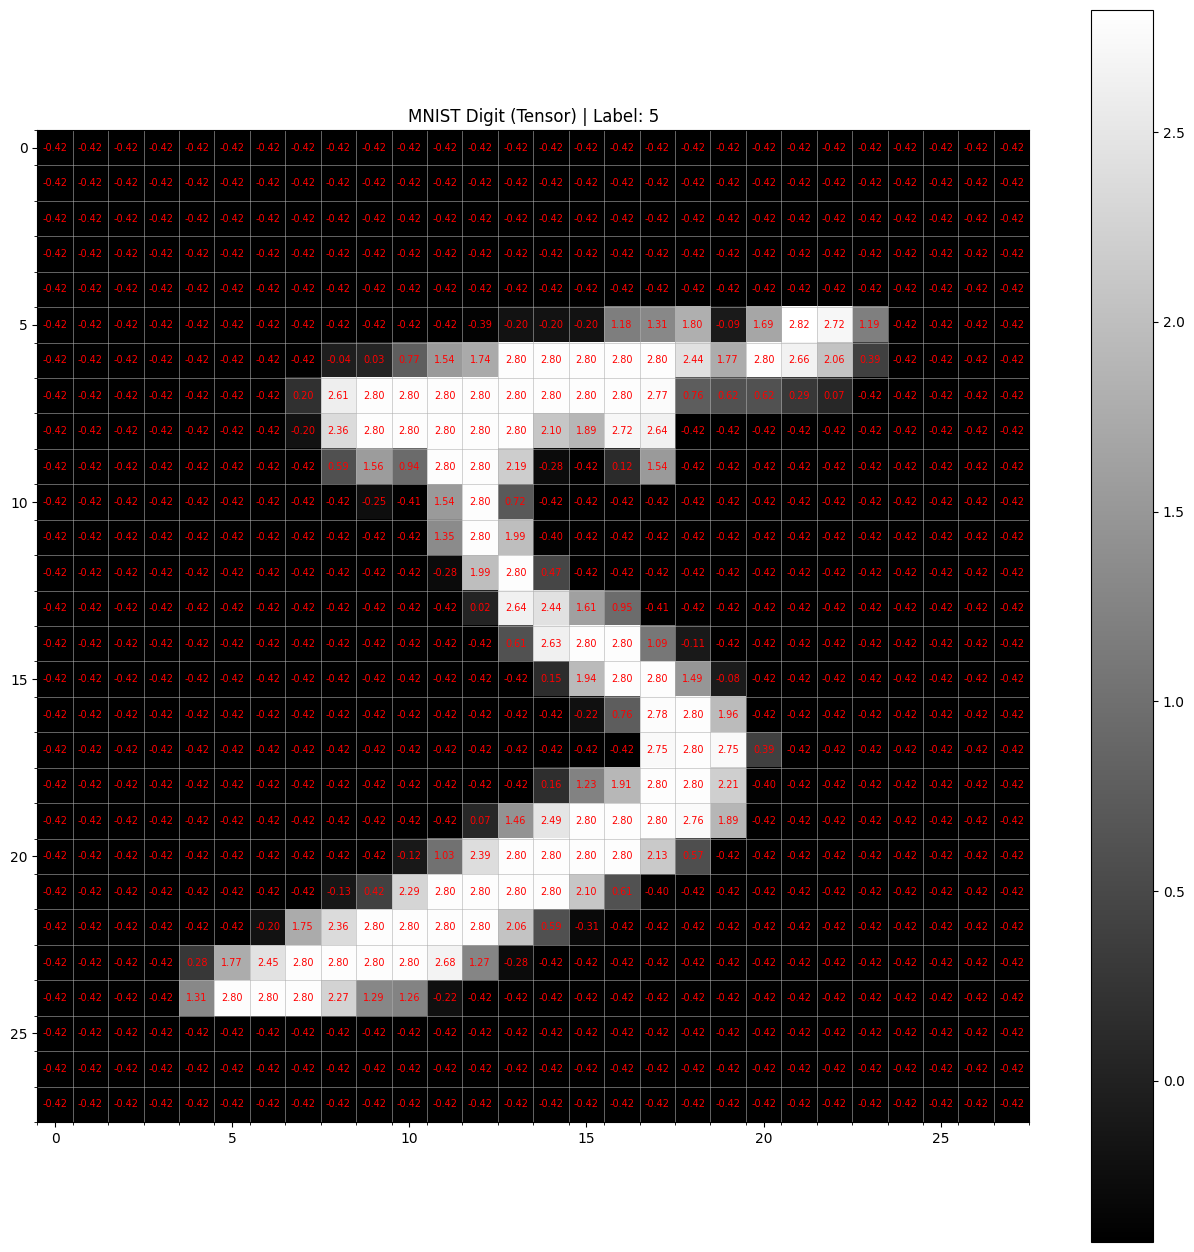

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Get transformed image
image, label = train_dataset[0]

# Convert (1, 28, 28) → (28, 28)
image_array = image.squeeze().numpy()

fig, ax = plt.subplots(figsize=(16, 16))

# Show transformed image
im = ax.imshow(
    image_array,
    cmap="gray",
    vmin=image_array.min(),
    vmax=image_array.max()
)

# Show ALL 784 normalized pixel values
for i in range(28):
    for j in range(28):
        value = image_array[i, j]

        ax.text(
            j, i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="red"
        )

# Grid around every pixel
ax.set_xticks(np.arange(-0.5, 28, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 28, 1), minor=True)
ax.grid(which="minor", linewidth=0.4)

ax.set_title(f"MNIST Digit (Tensor) | Label: {label}")

plt.colorbar(im, ax=ax)
plt.show()

### Creating the Test Dataset

A separate test dataset is used to evaluate the model on images it has not seen during training.

- MNIST contains **10,000 test images**.
- `train=False` loads the test portion of the dataset.
- The **same transformations** used for the training images are also applied to the test images.

In [60]:
test_dataset=torchvision.datasets.MNIST(
    download=True,
    train=False,
    transform=transform,
    root='./data'
)

### Creating Data Loaders

`DataLoader` divides the dataset into smaller **batches** that are passed to the model.

- **Training DataLoader**
  - `batch_size=64` → Processes 64 images at a time.
  - `shuffle=True` → Randomizes the image order during each epoch.

- **Test DataLoader**
  - `batch_size=1000` → Uses larger batches since no training or gradient calculation is required.
  - `shuffle=False` → Shuffling is not necessary during evaluation.

In [61]:
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=1000,shuffle=False)

## Building the Neural Network

The model is created as a custom class that inherits from `nn.Module`.

- `__init__()` → Defines the layers of the neural network.
- `forward()` → Defines how the input data passes through those layers.

### Model Architecture

- `nn.Flatten()` → Converts each `28 × 28` image into a vector of **784 values**.
- `nn.Linear(784, 128)` → Maps 784 input pixels to 128 hidden features.
- `nn.ReLU()` → Adds non-linearity so the model can learn more complex patterns.
- `nn.Linear(128, 10)` → Produces 10 outputs, one for each digit from **0 to 9**.

In [62]:
class SimpleMNIST(nn.Module):  # nn.Module is the parent class
    def __init__(self):
        super().__init__()  # Call __init__() of the parent class
        
        self.flatten = nn.Flatten()  # Flatten image into one vector
        
        self.layers = nn.Sequential(  # Define model layers
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)  # 28×28 → 784
        x = self.layers(x)   # Pass through neural network
        return x             # Return 10 output scores

## Training the Model

Now that the data and model architecture are ready, the model can be trained on the MNIST dataset.

### Training Components

Three main components are required:

- **Model** → Create an instance of the neural network defined earlier.
- **Loss Function (`CrossEntropyLoss`)** → Measures how far the model's predictions are from the correct digit labels.
- **Optimizer (`Adam`)** → Updates the model's weights to reduce the loss.

The model and input data must also be on the **same device (CPU or GPU)** during training.

In [64]:
# Initialize model 
model=SimpleMNIST()

# define loss function
loss_function=nn.CrossEntropyLoss()

# define optimizer
optimizer=optim.Adam(model.parameters(),lr=0.001)

### Defining the Training Function

The training function performs **one complete epoch** over the training dataset.

For each batch, the model performs the following steps:

1. Clear the previous gradients.
2. Perform a forward pass to get predictions.
3. Calculate the loss.
4. Perform backpropagation to calculate gradients.
5. Update the model weights using the optimizer.

The function also tracks the **loss and accuracy** during training to monitor the model's progress.

In [70]:
def train_epoch(model,loss_function,optimizer,train_loader,device):
    model=model.to(device) # Move the device to GPU
    model.train() # set model to traning mode
    
    # Initialize value as 0
    epoch_loss=0.0
    running_loss=0.0
    total_prediction=0
    num_correct_prediction=0

    # total number of batches in one epoch
    total_batch=len(train_loader)


    for batch_idx,(input,target) in enumerate(train_loader):
        input,target=input.to(device),target.to(device) # move input and target to gpu device
        optimizer.zero_grad() # clear old gradient from previous epoch
        ouput=model(input) # make prediction
        loss=loss_function(ouput,target) # calculate loss
        loss.backward() # compute gradient
        optimizer.step() # update parameters

        # Loss tracking for report
        loss_value=loss.item() # Convert tensor to python number
        epoch_loss+=loss_value
        running_loss+=loss_value

        # Calculate accuracy metrics for current batch
        _,predicted_indices=ouput.max(1) # find the predicted index
        batch_size=target.size(0) # get current batch size
        total_prediction+=batch_size
        num_correct_in_batch=predicted_indices.eq(target).sum().item()
        num_correct_prediction+=num_correct_in_batch

        # Check if it is time to print report
        if (batch_idx+1)%134 ==0 or (batch_idx+1) == total_batch:
            # Calculate average loss and accuracy for current 
            avg_running_loss=running_loss/134
            accuracy=100* num_correct_prediction/total_prediction

            # Print the progress update
            print(f"Step {batch_idx+1}/{total_batch} - Loss: {avg_running_loss:.3f} | Acc: {accuracy:.3f}")

            # reset tracker for next reporting interval
            running_loss=0.0
            num_correct_prediction=0
            total_prediction=0
    # Calculate average loss for entire epoch
    aver_epoch_loss=epoch_loss/total_batch

    # return model , loss
    return model,aver_epoch_loss
            
        
        
    

### Evaluating the Model

After training, the model is evaluated on the **test dataset** to check how well it performs on unseen images.

- `model.eval()` → Sets the model to evaluation mode.
- `torch.no_grad()` → Disables gradient calculations, making evaluation faster and more memory-efficient.
- The model performs only a **forward pass** to make predictions.
- Predicted classes are compared with the actual labels to calculate accuracy.

During evaluation, there is **no backpropagation or weight update**.

In [71]:
def evaluate(model,test_loader,device):
    model.eval() # set model in evaluation mode
    num_correct_prediction=0
    total_prediction=0

    # disable gradient calculation to save memory
    with torch.no_grad():
        for input, target in test_loader:
            input,target=input.to(device),target.to(device) # move input and target to gpu
            output=model(input) # make prediction
            _,prediction_indices=output.max(1) # get the prediction index
            batch_size=target.size(0)
            total_prediction+=batch_size
            correct_prediction=prediction_indices.eq(target)# check if prediction is same as target
            num_correct_in_batch=correct_prediction.sum().item()
            num_correct_prediction+=num_correct_in_batch
            
    # overall accuracy 
    accuracy_percentage= (num_correct_prediction/total_prediction)*100
    print(f"Accuracy - {accuracy_percentage:.3f} ")
    return accuracy_percentage
    
            
            

### Training Loop

The model is trained for multiple **epochs**, where each epoch represents one complete pass through the training dataset.

For each epoch:

1. `train_epoch()` → Trains the model and updates its weights.
2. `evaluate()` → Tests the model on unseen test data.
3. Training loss and test accuracy are stored to track the model's performance over time.

Repeating this process allows the model to gradually improve its predictions.

In [72]:
# set epoch
num_epoch=5

# set empty array for analysis
train_loss=[]
test_acc=[]

# Begin train and evaluate process
for epoch in range(num_epoch):
    print(f"\n [Training ] Epoch {epoch+1}: ")
    # call traning function
    trained_model,loss=train_epoch(model,loss_function,optimizer,train_loader,device)
    # store loss for each epoch
    train_loss.append(loss)

    print(f"[Testing] Epoch {epoch+1}: ")
    # Call evaluatio function 
    accuracy=evaluate(trained_model,test_loader,device)
    # store accuracy for each epoch
    test_acc.append(accuracy)


 [Training ] Epoch 1: 
Step 134/938 - Loss: 1.477 | Acc: 62.990
Step 268/938 - Loss: 0.679 | Acc: 84.585
Step 402/938 - Loss: 0.501 | Acc: 87.628
Step 536/938 - Loss: 0.412 | Acc: 89.272
Step 670/938 - Loss: 0.370 | Acc: 90.240
Step 804/938 - Loss: 0.359 | Acc: 89.949
Step 938/938 - Loss: 0.326 | Acc: 91.023
[Testing] Epoch 1: 
Accuracy - 91.520 

 [Training ] Epoch 2: 
Step 134/938 - Loss: 0.302 | Acc: 91.768
Step 268/938 - Loss: 0.301 | Acc: 91.290
Step 402/938 - Loss: 0.282 | Acc: 92.048
Step 536/938 - Loss: 0.285 | Acc: 91.779
Step 670/938 - Loss: 0.277 | Acc: 92.118
Step 804/938 - Loss: 0.277 | Acc: 91.943
Step 938/938 - Loss: 0.255 | Acc: 92.662
[Testing] Epoch 2: 
Accuracy - 93.130 

 [Training ] Epoch 3: 
Step 134/938 - Loss: 0.240 | Acc: 93.004
Step 268/938 - Loss: 0.252 | Acc: 92.980
Step 402/938 - Loss: 0.238 | Acc: 93.342
Step 536/938 - Loss: 0.223 | Acc: 93.937
Step 670/938 - Loss: 0.226 | Acc: 93.505
Step 804/938 - Loss: 0.227 | Acc: 93.342
Step 938/938 - Loss: 0.216 | A

## Analyzing Model Performance

After training, the model's performance can be analyzed using its predictions and training metrics.

### Visualizing Predictions

Random images from the **test dataset** are passed through the trained model to compare:

- **Actual label** → The correct digit.
- **Predicted label** → The digit predicted by the model.

This helps visually identify both correct and incorrect predictions.

In [74]:
import matplotlib.pyplot as plt
import torch

def display_predictions(model, test_loader, device):
    
    model.eval()
    
    # Store one image from each class (0-9)
    samples = {}
    
    with torch.no_grad():
        
        for inputs, targets in test_loader:
            
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            # Make predictions
            outputs = model(inputs)
            _, predicted_indices = outputs.max(1)
            
            # Check images in the batch
            for i in range(len(targets)):
                
                label = targets[i].item()
                
                # Store only one image for each digit
                if label not in samples:
                    samples[label] = (
                        inputs[i].cpu(),
                        predicted_indices[i].item()
                    )
                
                # Stop once we have digits 0-9
                if len(samples) == 10:
                    break
            
            if len(samples) == 10:
                break

    # Plot images
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.flatten()

    for digit in range(10):
        
        image, prediction = samples[digit]
        
        # (1, 28, 28) -> (28, 28)
        image = image.squeeze()
        
        axes[digit].imshow(image, cmap="gray")
        axes[digit].set_title(
            f"True: {digit}\nPred: {prediction}",
            fontsize=9
        )
        axes[digit].axis("off")

    plt.suptitle("Model Predictions for a Sample of Each Class")
    plt.tight_layout()
    plt.show()

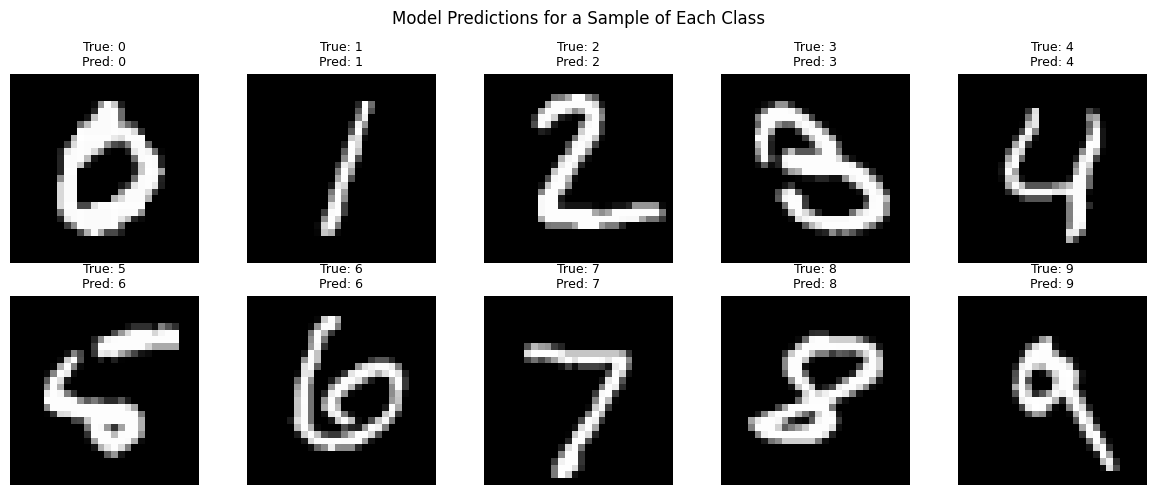

In [75]:
display_predictions(trained_model, test_loader, device)